## Oppgave 4
### a)

### Importerer biblioteker

In [78]:
import numpy as np
from matplotlib import pyplot as plt
import random
import plotly.graph_objects as go

In [79]:
"""Må inkludere disse bibliotekene for å plotte."""
# !pip install pandas
# !pip install plotly

'Må inkludere disse bibliotekene for å plotte.'

In [80]:
"""Oppretter først funksjonene. Definerer så variablene."""

# Bruker liste til å lagre posisjonene, for da vil vi kunne bruke det som indekser.
def MakeParticles(params, Np = False):   
    # I 4b) tar vi inn forskjellige størrelser.
    if Np == False:
        count = params["Np"]
    else:
        count = Np
    L = params["L"]
    size = params["b"]

    if (count) * (size) > L:
        print("Illegal size and particleamount. \n" \
        "Setting Particlecount to 1.")
        count = 1
        params["Np"] = count
            
    initParticlePos = np.linspace(0, L-size, count)

    listPosition = []

    for n in range(len(initParticlePos)):
        listPosition.append(int(initParticlePos[n]))
    
    # print(listPosition)
    return listPosition

In [81]:
#Potensialer
def V1(x, params):                #uten k fordi den inngår i p_pos
    Nx = params["Nx"]
    alfa = params["alfa"]
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return -(periode-Nx)/((1-alfa)*Nx)

def V2(x, params):                          #også uten k for samme grunn
    return 0

In [82]:
#Henholdsvise sannsynlighetsfunksjoner p+, p0 og p-
def p_pos(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    #får litt numerisk overflow hvis jeg ikke clipper
    arg1 = np.clip(-beta_k*(V((x-1) % L, params) - V((x+1) % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x % L, params) - V((x+1) % L, params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner


def p_0(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x-1) % L, params) - V(x % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V((x+1) % L, params) - V(x % L, params)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    
    return 1/nevner


def p_neg(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]
    arg1 = np.clip(-beta_k*(V((x+1) % L, params) - V( (x-1) % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V( x % L, params) - V((x-1) % L, params)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner

def lookUpTabell_V1(params):
    L = params["L"]
    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    V = V1    # Her bruker vi potensial V1!
    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V, params)
        tabell_V1_p_neg[x] = p_neg(x, V, params)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2(params):
    L = params["L"]
    p_pos_val = p_pos(1, V2, params)
    p_neg_val = p_neg(1, V2, params)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg

In [83]:
params4a = {
    "alfa"      : 0.2,
    "Tp"        : 40,       # Tid for 0.5 periode
    "Nx"        : 20,
    "beta_k"    : 1000,
    "Np"        : 30,        # Velg et fint antall
    "b"         : 2,        # Størrelse. Velg en fin størrelse. Kan lage en funksjon her.
}
params4a["L"] = 4*params4a["Nx"]   # = 80
params4a["timeSteps"] = 10*params4a["Tp"]

# params4a["initPosition"] = MakeParticles(params4a)

params4a["tabell_V1_p_pos"], params4a["tabell_V1_p_neg"] = lookUpTabell_V1(params4a)
params4a["tabell_V2_p_pos"], params4a["tabell_V2_p_neg"] = lookUpTabell_V2(params4a)


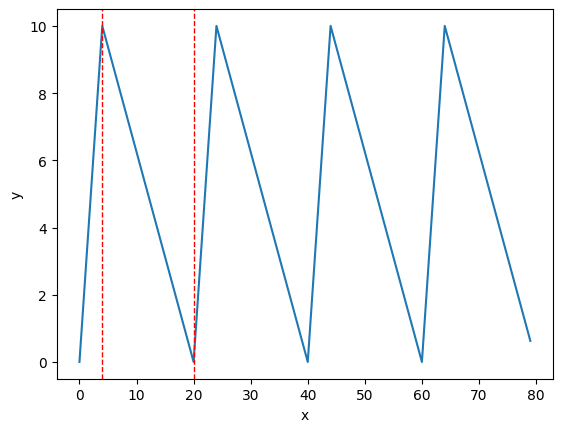

In [84]:
""" Du trenger ikke ha med dette Johannes"""

# Prøver å forstå alt sammen. Tegner potensialet.
# Må modifisere litt. Kan ikke sammenligne et helt array med periode, siden hver verdi for forskjellig bool-verdi.

alfa = 0.2
def V1_test(x):
    potensialer = np.zeros_like(x, dtype = float)    # Viktig å endre datatype. Hvis ikke blir verdiene til int.
    for i in range(len(x)):
        Hvor_i_periode = x[i] % params4a["Nx"]
        if Hvor_i_periode <= alfa*params4a["Nx"]:
            potensialer[i] = 10*Hvor_i_periode / (alfa* params4a["Nx"])
        else:
            potensialer[i] = -10*(Hvor_i_periode - params4a["Nx"])/((1-alfa)*params4a["Nx"]) 
    return potensialer
    
x_axis = np.arange(0, params4a["L"], 1)
y_potential = V1_test(x_axis)
plt.plot(x_axis, V1_test(x_axis))
plt.xlabel("x")
plt.ylabel("y")
plt.axvline(x=4, color='red', linestyle='--', linewidth=1, label='x=2')
plt.axvline(x=20, color='red', linestyle='--', linewidth=1, label='x=20')
plt.show()

In [85]:
# Optimalisering. Siden partiklene bare kan bevege steg med lengde 1,
# så behøver vi bare å sjekke forrige/neste partikkel.
# Bruker OMG-metoden. vi lagrer bare plasseringen til partiklene sin venstre posisjon, og sjekker denne+-size for å sjekke om det blir kollisjon.

def enSimulasjon_4a(params):
    params["initPosition"] = MakeParticles(params)
    particlePos = params["initPosition"].copy()
    print(particlePos)
    Np = params["Np"]
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    b = params["b"]

    tabell_V1_p_pos = params["tabell_V1_p_pos"] 
    tabell_V1_p_neg = params["tabell_V1_p_neg"]
    tabell_V2_p_pos = params["tabell_V2_p_pos"]
    tabell_V2_p_neg = params["tabell_V2_p_neg"]
    positionsOverTime = []
    queue = list(range(Np))

    # optimalisering. Random array
    rng = np.random.default_rng()
    random_values = rng.random(timeSteps*Np)

    positionsOverTime.append(particlePos.copy())

    for k in range(timeSteps):
        rng.shuffle(queue)
        whichPotential = ( k // Tp) % 2    
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        for index in queue:

            tilfeldigtall = random_values[Np*k + index]       #Genererer først tilfeldige tall
            x = particlePos[index]
            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if ((x-1) % L) == (((particlePos[(index-1)% Np]) + (b-1)) % L):
                    continue
                x -= 1

            elif tilfeldigtall >= (1 - tabell_p_pos[x % L]):
                if (((x+1) + (b-1)) % L) == ((particlePos[(index+1) % Np]) % L):
                    continue
                x += 1
            particlePos[index] = x % (L)

        positionsOverTime.append(particlePos.copy())
    return positionsOverTime

In [86]:
def plotPositions(params):
    positions_over_time = enSimulasjon_4a(params4a)
    # print(positions_over_time[0])
    num_balls = len(positions_over_time[0])
    Tp = params["Tp"]
    L = params["L"]


    # Initial figure
    fig = go.Figure(
        data=[
            go.Scatter(
                x=positions_over_time[0],
                y=[10]* num_balls,
                mode="markers",
                marker=dict(size=12)
            ),
            go.Scatter(
                x=x_axis,
                y= y_potential,
                mode="lines",
                name="Potential 1"
            ),
            go.Scatter(
                x= x_axis,
                y = [10]*len(x_axis),
                mode = "lines",
                name = "Potential 2"
            )
        ]
    )
    

    # Create frames
    frames = []
    for t, positions in enumerate(positions_over_time):
        whichPotential = ( t // Tp) % 2
        if whichPotential == 0:
            potensial = "Sagtann"
            particle_y=[y_potential[coord] for coord in positions]

        
        else:
            potensial = "flatt"
            particle_y = [10]*num_balls
        frames.append(
            go.Frame(
                data=[
                    go.Scatter(x=positions, y=particle_y),
                ],
                layout= go.Layout(
                    annotations=[
                        dict(
                            text=f"Frame: {t}, potensial = {potensial}",
                            x=0.95,
                            y=0.95,
                            xref = "paper",
                            yref = "paper",
                            showarrow = False,
                            font=dict(size=20)
                        )
                    ]
                ),
                name=str(t)
            )   
        )

    fig.update_layout(
        title = f'Antall partikler = {num_balls}, størrelse = {params["b"]}.'
    )

    # Add slider (frame counter)
    fig.update_layout(
        sliders=[{
            "currentvalue": {"prefix": "Frame: "},
            "steps": [
                {
                    "args": [[f.name], {"frame": {"duration": 10, "redraw": False},
                                        "mode": "immediate"}],
                    "label": f.name,
                    "method": "animate"
                }
                for f in frames
            ]
        }]
    )

    # Add play button
    fig.update_layout(
        xaxis=dict(range=[-1, L], title="Position"),
        yaxis=dict(range=[-10, 20]),
        updatemenus=[
            dict(
                type="buttons",
                buttons=[
                    dict(
                        label="Play",
                        method="animate",
                        args=[None, {"frame": {"duration": 300, "redraw": False},
                                    "fromcurrent": True}]

                    ), dict(
                        label = "Pause",
                        method = "animate",
                        args =[[None], {"frame": {"duration": 0, "redraw": False},
                              "mode": "immediate"}]
                    )
                ]
            )
        ]
    )


    fig.frames = frames
    fig.show()

In [87]:
""" Kan endre på størrelse og antall partikler her."""
# params4a["Np"] = 0
# params4a["b"] = 1
plotPositions(params4a)

[0, 2, 5, 8, 10, 13, 16, 18, 21, 24, 26, 29, 32, 34, 37, 40, 43, 45, 48, 51, 53, 56, 59, 61, 64, 67, 69, 72, 75, 78]


#### Oppgave 4b)

Legger inn flere funksjoner

In [88]:
def rho(params, Np = False):
    if Np == False:
        particleCount = params["Np"]
    else:
        particleCount = Np
    return params["b"]*particleCount/(params["Ns"]*params["Nx"])


In [89]:
params4b = {
    "beta_k"  : 1000,
    "Nx"      : 100,
    "Tp"      : 300,  # Tid for en halvperiode.
    "Ns"      : 10,
    "alfa"    : 0.2,
    "b"       : 20,   # Størrelse på partiklene.
    "Nc"      : 100,  # Antall halvperioder. 
    "Np"      : 0 # Denne skal varieres for å danne forskjellige tetthet rho. Endres inne i funksjonen.
}
params4b["L"] = params4b["Ns"]*params4b["Nx"]
params4b["timeSteps"] = params4b["Tp"]*params4b["Nc"]  # 30000

# params4b["initPositions"] = MakeParticles(params4b)   # Denne må lages i funksjonen

params4b["tabell_V1_p_pos"], params4b["tabell_V1_p_neg"] = lookUpTabell_V1(params4b)
params4b["tabell_V2_p_pos"], params4b["tabell_V2_p_neg"] = lookUpTabell_V2(params4b)


In [90]:
def particleCurrent_sim(params):
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    Np = params["Np"]
    b = params["b"]
    tabell_V1_p_pos = params["tabell_V1_p_pos"] 
    tabell_V1_p_neg = params["tabell_V1_p_neg"]
    tabell_V2_p_pos = params["tabell_V2_p_pos"]
    tabell_V2_p_neg = params["tabell_V2_p_neg"]
    particlePos = params["initPosition"].copy()
    particleCurrent = np.zeros(timeSteps)
    
    queue = list(range(Np))

    rng = np.random.default_rng()
    random_values = rng.random(timeSteps*Np)

    for k in range(timeSteps):
        rng.shuffle(queue)
        whichPotential = ( k // Tp) % 2
        n_pos = 0
        n_neg = 0
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        for index in queue:
            tilfeldigtall = random_values[Np*k + index]       #Plukker ut tilfeldig genererte tall.
            x = particlePos[index]


            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if ((x-1) % L) == ((particlePos[(index-1) % Np] + (b-1)) % L):
                    continue
                x -= 1
                n_neg += 1
            elif tilfeldigtall >= (1 - tabell_p_pos[x % L]):
                if (((x+1) + (b-1)) % L) == (particlePos[(index+1) % Np] % L):
                    continue
                x += 1
                n_pos += 1

            particlePos[index] = x % (L)
        
        if Np == 0:
            Np = 1
        particleCurrent[k] = (n_pos - n_neg)/Np

    averageCurrent = np.sum(particleCurrent)/len(particleCurrent)
    
    return averageCurrent, particleCurrent

In [91]:
def Oppgave4b(params):
    minNp = 0
    maxNp = int(params["Nx"]*params["Ns"]/params["b"])
    Np = np.arange(minNp, maxNp+1, 1)                 # Kollisjonen funker ikke
    rhoList = np.zeros(len(Np))
    averageCurrentList = np.zeros(len(Np))

    plt.xlabel("Particle density")
    plt.ylabel("Average Current")

    for i in range(len(Np)):
        params["Np"] = Np[i]
        params["initPosition"] = MakeParticles(params)
        averageCurrent, _ = particleCurrent_sim(params)
        rhoList[i] = (rho(params, Np[i]))
        averageCurrentList[i] = averageCurrent

    plt.plot(rhoList, averageCurrentList, label = "Plotting average current")
    plt.grid(True)
    plt.show()        

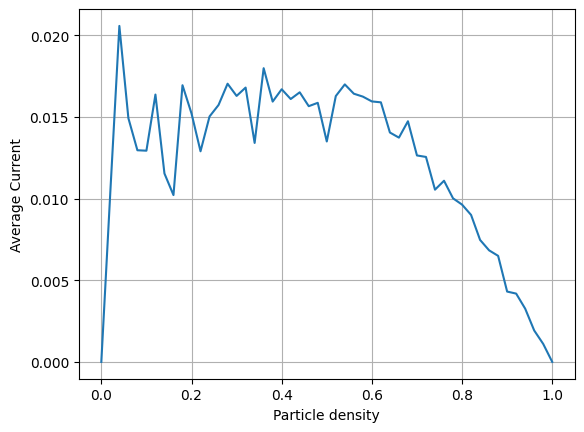

In [92]:
Oppgave4b(params4b)

In [93]:
# params5 = params4b.copy()
# params5["Np"] =20
# params5["Nc"] =6
# params5["Tp"] =100
# params5["b"] = 10
# tid =100

# params5["timeSteps"] = params5["Nc"]*params5["Tp"]
# params5["initPosition"] = MakeParticles(params5)


# aCurrent, current_time = particleCurrent_sim(params5)
# axis = np.arange(0, params5["timeSteps"])
# plt.figure()
# plt.plot(axis, current_time)
# plt.show()

In [94]:
params4c = {
    "beta_k"  : 1000,
    "Nx"      : 100,
    "Tp"      : 300,  # Tid i et potensial
    "Ns"      : 10,
    "alfa"    : 0.2,  #Skaper positiv strøm.
    "b"       : 20,   # Størrelse på partiklene.
    "Nc"      : 100,  # Antallhalvperioder.
    "Np"      : 0 # Denne skal varieres for å danne forskjellige tetthet rho.
}
params4c["L"] = params4c["Ns"]*params4c["Nx"]
params4c["timeSteps"] = params4c["Tp"]*params4c["Nc"]

# params4c["initPositions"] = MakeParticles(params4c)  Denne må lages i funksjonen

params4c["tabell_V1_p_pos"], params4c["tabell_V1_p_neg"] = lookUpTabell_V1(params4c)
params4c["tabell_V2_p_pos"], params4c["tabell_V2_p_neg"] = lookUpTabell_V2(params4c)

In [95]:
def Oppgave4c(params):
    # KJører 4b) flere ganger. Endrer på Tp og Nc.
    # Nc_array = np.linspace(1, 30000, 10)  # Bør ikke ha jevnt stiigende verider.
    Nc_array = np.array([1, 2, 10, 50, 100, 500, 1000, 5000, 10000, 30000])
    # Nc_array =np.array([100])
    Tp_array = (30000 / Nc_array)
    for i in range(len(Nc_array)):
        params["Tp"] = Tp_array[i]
        params["Nc"] = Nc_array[i]
        print(f'Tid på et potensial Tp = {Tp_array[i]}')
        print(f'Antall sykluser Nc = {Nc_array[i]}')
        Oppgave4b(params)

Tid på et potensial Tp = 30000.0
Antall sykluser Nc = 1


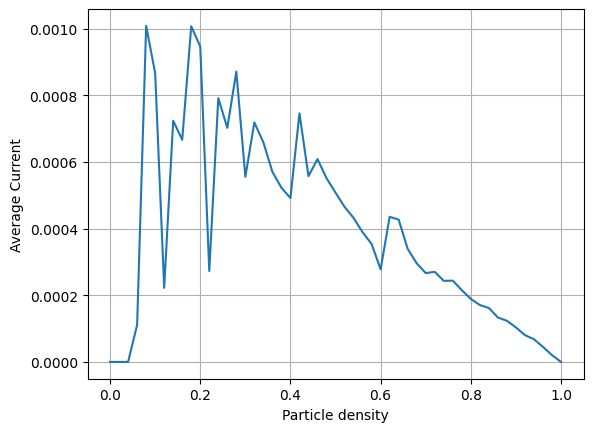

Tid på et potensial Tp = 15000.0
Antall sykluser Nc = 2


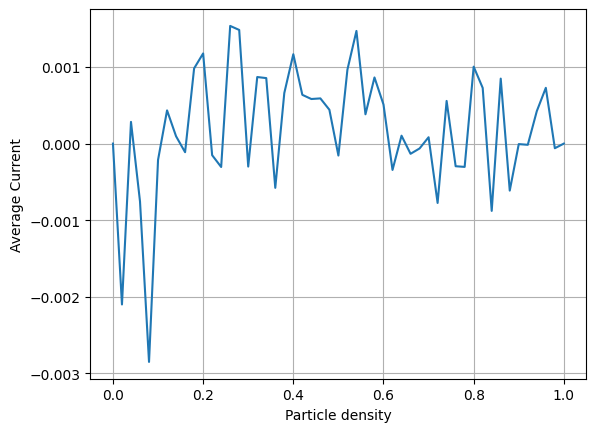

Tid på et potensial Tp = 3000.0
Antall sykluser Nc = 10


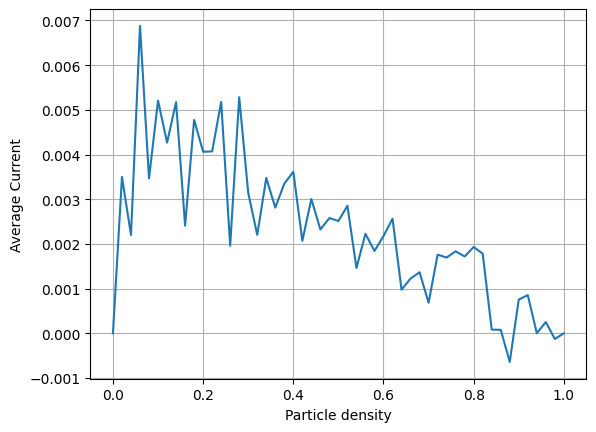

Tid på et potensial Tp = 600.0
Antall sykluser Nc = 50


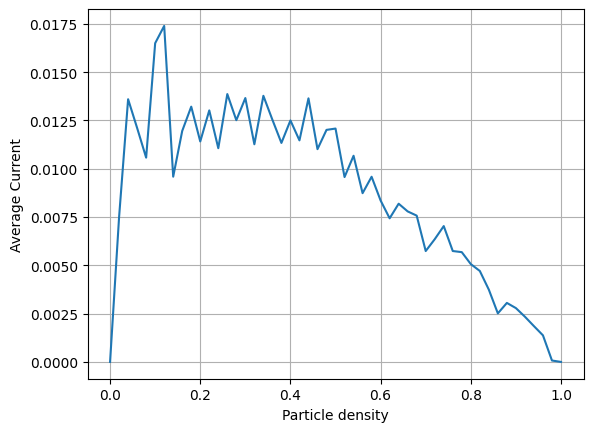

Tid på et potensial Tp = 300.0
Antall sykluser Nc = 100


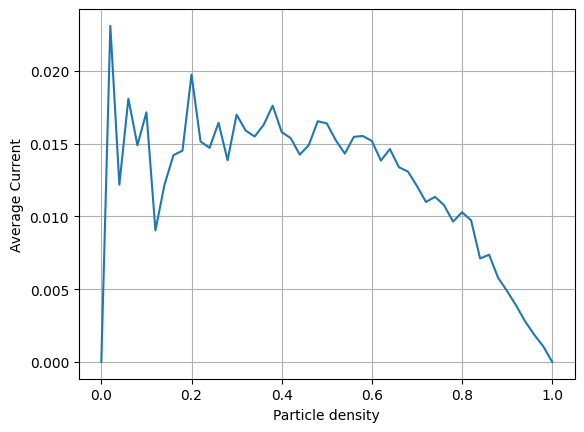

Tid på et potensial Tp = 60.0
Antall sykluser Nc = 500


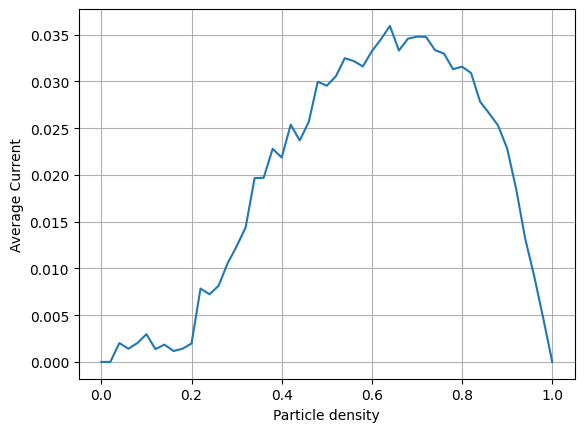

Tid på et potensial Tp = 30.0
Antall sykluser Nc = 1000


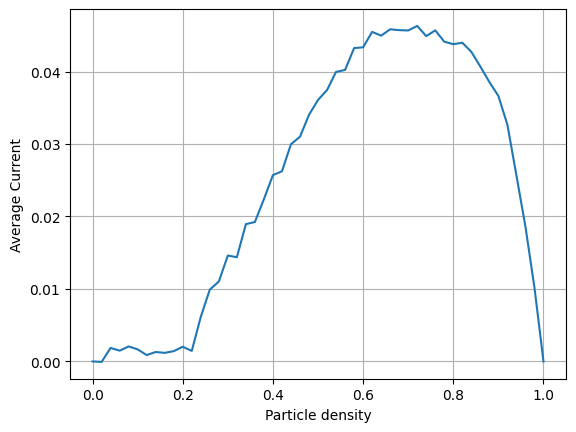

Tid på et potensial Tp = 6.0
Antall sykluser Nc = 5000


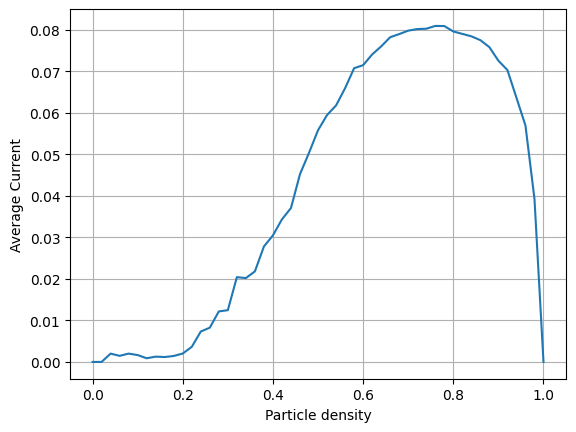

Tid på et potensial Tp = 3.0
Antall sykluser Nc = 10000


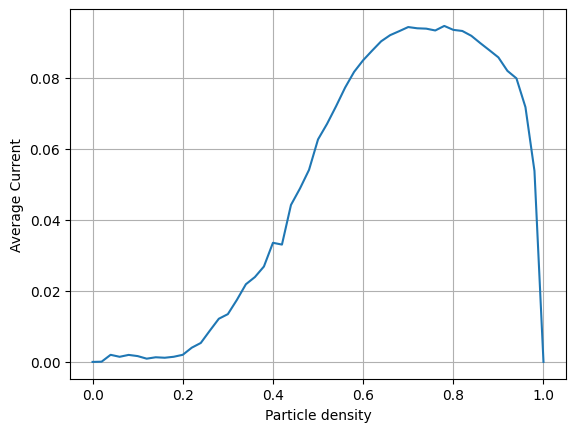

Tid på et potensial Tp = 1.0
Antall sykluser Nc = 30000


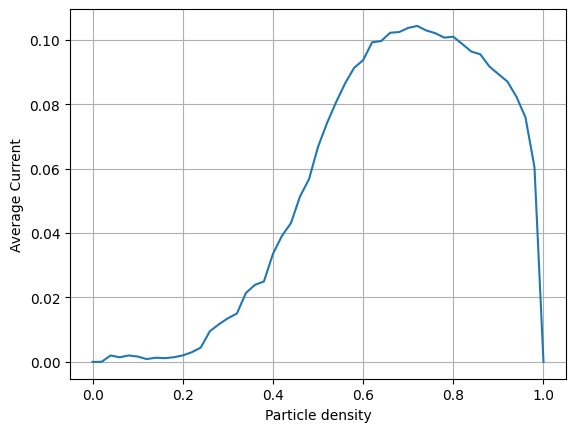

In [96]:
plt.close('all')
Oppgave4c(params4c)

## Oppgave 4d)

Vi skal nå finne en graf fra en naturvitenskapelig artikkel som handler om browninan motiton i en hard core repulsion flashing ratchet system, slik at vi kan sammenligne hard core repulsion med ikke-agerende

Her er linken til artikkelen Johannes.
Se på graf om hard core repulsion. Diskuter den.
https://arxiv.org/html/2512.14891v1